In [62]:
import pandas as pd 
import numpy as np 

In [63]:
import sys
sys.executable

'c:\\Users\\thelm\\AppData\\Local\\Programs\\Python\\Python313\\python.exe'

In [64]:
df = pd.read_excel('data/Microsoft_LinkedIn_Processed.xlsx')
df

,Date,Close,High,Low,Open,Volume,change_tomorrow,change_tomorrow_direction
0,2016-12-08,55.079998,55.594599,54.926523,55.341812,21220800,1.549152,UP
1,2016-12-09,55.946697,55.964754,55.188343,55.233482,27349400,0.321693,UP
2,2016-12-12,56.127254,56.244620,55.720996,55.811275,20198100,1.286142,UP
3,2016-12-13,56.858536,57.255768,56.190463,56.425191,35718900,-0.478626,DOWN
4,2016-12-14,56.587692,57.282851,56.452270,56.876589,30352700,-0.159799,DOWN
...,...,...,...,...,...,...,...,...
2120,2025-05-16,454.269989,454.359985,448.730011,452.049988,23849800,1.002464,UP
2121,2025-05-19,458.869995,459.589996,450.799988,450.880005,21336500,-0.152778,DOWN
2122,2025-05-20,458.170013,458.339996,454.320007,455.589996,15441800,-1.237379,DOWN
2123,2025-05-21,452.570007,457.779999,451.809998,454.570007,19216900,0.503447,UP


In [65]:
##df.drop??

In [66]:
#when dev an ml model, have to 1st ask which var we want to predict
target = df.change_tomorrow_direction

#vars to parse into the model - expnatory - vars to calculate the prediction
explanatory = df.drop(columns=['change_tomorrow','change_tomorrow_direction'])

In [67]:
!"{sys.executable}" -m pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
from sklearn.tree import DecisionTreeClassifier
#predicting a catergroy rather than a ontinous output thf use classfied 

In [69]:
#instance for the class 
model_dt = DecisionTreeClassifier()

In [70]:
print(explanatory.shape)

(2125, 6)


In [71]:
print(explanatory.dtypes)

Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object


In [72]:
explanatory_dates = explanatory['Date']
explanatory_dates

0      2016-12-08
1      2016-12-09
2      2016-12-12
3      2016-12-13
4      2016-12-14
          ...    
2120   2025-05-16
2121   2025-05-19
2122   2025-05-20
2123   2025-05-21
2124   2025-05-22
Name: Date, Length: 2125, dtype: datetime64[ns]

In [73]:
explanatory.drop(columns='Date', inplace=True) # have to drop date in place 
#ml models don't like dates, so we have to drop it
print(explanatory.shape)
print(explanatory.dtypes)

(2125, 5)
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [74]:
target

0         UP
1         UP
2         UP
3       DOWN
4       DOWN
        ... 
2120      UP
2121    DOWN
2122    DOWN
2123      UP
2124    DOWN
Name: change_tomorrow_direction, Length: 2125, dtype: object

In [75]:
#this func calc the mathecial eqxn to predict the target var 
model_dt.fit(X=explanatory, y=target)

DecisionTreeClassifier()

[Text(0.5408068521877736, 0.9878048780487805, 'Close <= 224.427\ngini = 0.497\nsamples = 2125\nvalue = [978, 1147]'),
 Text(0.4490077319283576, 0.9634146341463414, 'Close <= 215.929\ngini = 0.491\nsamples = 1068\nvalue = [461, 607]'),
 Text(0.4949072920580656, 0.975609756097561, 'True  '),
 Text(0.37102006243113345, 0.9390243902439024, 'Volume <= 44742700.0\ngini = 0.493\nsamples = 1030\nvalue = [452, 578]'),
 Text(0.27303064693849144, 0.9146341463414634, 'Volume <= 32050200.0\ngini = 0.489\nsamples = 918\nvalue = [390, 528]'),
 Text(0.16799307264520666, 0.8902439024390244, 'Low <= 205.982\ngini = 0.495\nsamples = 739\nvalue = [333, 406]'),
 Text(0.1340622470961029, 0.8658536585365854, 'Volume <= 31751600.0\ngini = 0.493\nsamples = 722\nvalue = [319, 403]'),
 Text(0.1309696645093399, 0.8414634146341463, 'High <= 59.215\ngini = 0.492\nsamples = 716\nvalue = [313, 403]'),
 Text(0.06620059599789536, 0.8170731707317073, 'Close <= 58.538\ngini = 0.49\nsamples = 58\nvalue = [33, 25]'),
 Text

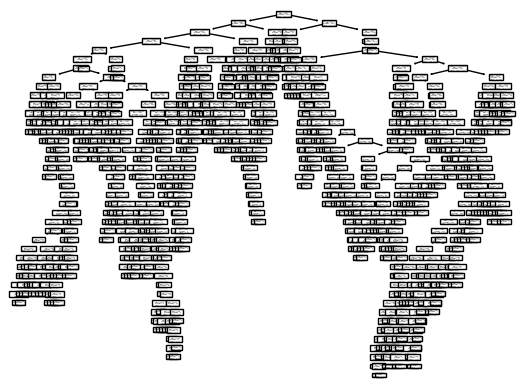

In [76]:
#Visualisations
from sklearn.tree import plot_tree 

plot_tree(decision_tree=model_dt, feature_names=model_dt.feature_names_in_)

[Text(0.6025641025641025, 0.9166666666666666, 'Close <= 224.427\ngini = 0.497\nsamples = 2125\nvalue = [978, 1147]'),
 Text(0.3717948717948718, 0.75, 'Close <= 215.929\ngini = 0.491\nsamples = 1068\nvalue = [461, 607]'),
 Text(0.48717948717948717, 0.8333333333333333, 'True  '),
 Text(0.20512820512820512, 0.5833333333333334, 'Volume <= 44742700.0\ngini = 0.493\nsamples = 1030\nvalue = [452, 578]'),
 Text(0.10256410256410256, 0.4166666666666667, 'Volume <= 32050200.0\ngini = 0.489\nsamples = 918\nvalue = [390, 528]'),
 Text(0.05128205128205128, 0.25, 'Low <= 205.982\ngini = 0.495\nsamples = 739\nvalue = [333, 406]'),
 Text(0.02564102564102564, 0.08333333333333333, 'gini = 0.493\nsamples = 722\nvalue = [319, 403]'),
 Text(0.07692307692307693, 0.08333333333333333, 'gini = 0.291\nsamples = 17\nvalue = [14, 3]'),
 Text(0.15384615384615385, 0.25, 'Volume <= 33995500.0\ngini = 0.434\nsamples = 179\nvalue = [57.0, 122.0]'),
 Text(0.1282051282051282, 0.08333333333333333, 'gini = 0.324\nsamples =

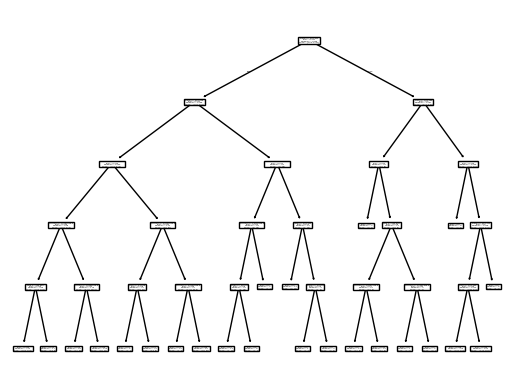

In [77]:
#shorten tree 
model_dt_shorter = DecisionTreeClassifier(max_depth=5)
model_dt_shorter.fit(X=explanatory, y=target)
plot_tree(decision_tree=model_dt_shorter, feature_names=model_dt_shorter.feature_names_in_)

In [78]:
#calc predictions - based on explanatory columns - parse info for each day 
# and calc what will happen to price of the stock tomorrow

y_pred = model_dt_shorter.predict(explanatory)

In [79]:
df_predictions = df[['change_tomorrow_direction']].copy()
df_predictions

,change_tomorrow_direction
0,UP
1,UP
2,UP
3,DOWN
4,DOWN
...,...
2120,UP
2121,DOWN
2122,DOWN
2123,UP


In [80]:
df_predictions['prediction'] = y_pred
df_predictions

,change_tomorrow_direction,prediction
0,UP,UP
1,UP,UP
2,UP,UP
3,DOWN,UP
4,DOWN,UP
...,...,...
2120,UP,UP
2121,DOWN,DOWN
2122,DOWN,DOWN
2123,UP,UP


In [81]:
#evaluate the model - how well it predicts the target var
comp = df_predictions.change_tomorrow_direction == df_predictions.prediction

In [82]:
comp.sum()

np.int64(1229)

In [83]:
len(comp)

2125

In [84]:
accuracy = comp.sum() / len(comp)
accuracy #57% of the days right 

np.float64(0.5783529411764706)

In [85]:
#compare predcitions to actual values
model_dt_shorter.score(explanatory, target)


0.5783529411764706

In [86]:
#ideally want accuracy of ml model > 80%
#thf using max tree depth 
model_dt.predict(explanatory)
model_dt.score(explanatory, target) #perfect score 

1.0

In [87]:
#save model to file 
import pickle #saving and loading objs to/from files
import os 

In [88]:
#os.makedirs('models')

In [89]:
with open('models/model_dt_classification.pkl', 'wb') as f: 
    pickle.dump(model_dt, f) #seriealise/converts model to bite stream and writes to file f

#wb = write binary - req for saving  obj w pickle 
#f = file 

### First configs of strategy class 

In [90]:
with open('models/model_dt_classification.pkl', 'rb') as f:
    model_dt_pickled = pickle.load(f)

In [91]:
model_dt_pickled

DecisionTreeClassifier()

In [92]:
#load dataste of mcirsofot stock 

df = pd.read_excel('data/Microsoft_LinkedIn_Processed.xlsx', index_col=0, parse_dates=['Date'])
df

,Close,High,Low,Open,Volume,change_tomorrow,change_tomorrow_direction
Date,,,,,,,
2016-12-08,55.079998,55.594599,54.926523,55.341812,21220800,1.549152,UP
2016-12-09,55.946697,55.964754,55.188343,55.233482,27349400,0.321693,UP
2016-12-12,56.127254,56.244620,55.720996,55.811275,20198100,1.286142,UP
2016-12-13,56.858536,57.255768,56.190463,56.425191,35718900,-0.478626,DOWN
2016-12-14,56.587692,57.282851,56.452270,56.876589,30352700,-0.159799,DOWN
...,...,...,...,...,...,...,...
2025-05-16,454.269989,454.359985,448.730011,452.049988,23849800,1.002464,UP
2025-05-19,458.869995,459.589996,450.799988,450.880005,21336500,-0.152778,DOWN
2025-05-20,458.170013,458.339996,454.320007,455.589996,15441800,-1.237379,DOWN


In [93]:
#how to implement investment stratgy 
#backtesting.py library - backtesting investment strategies

In [94]:
!"{sys.executable}" -m pip install backtesting


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [95]:
from backtesting import Backtest

In [96]:
##Backtest??

In [97]:
df_explanatory = df.drop(columns=['change_tomorrow', 'change_tomorrow_direction'])

In [98]:
model_dt_pickled.predict(df_explanatory) #get as many predictions as rows in df

array(['UP', 'UP', 'UP', ..., 'DOWN', 'UP', 'DOWN'],
      shape=(2125,), dtype=object)

In [99]:
explanatory_today = df_explanatory.iloc[[-1], :]
#seperate by rows and columns = , 
#take all the columns = : 
#take only the last row = -1 
#make tthe obj as dataframe = [-1]

In [100]:
forecast_tomorrow = model_dt_pickled.predict(explanatory_today)[0] #get the first element of the array - 0th index

In [101]:
df[['change_tomorrow_direction']].head(10)

,change_tomorrow_direction
Date,
2016-12-08,UP
2016-12-09,UP
2016-12-12,UP
2016-12-13,DOWN
2016-12-14,DOWN
2016-12-15,DOWN
2016-12-16,UP
2016-12-19,DOWN
2016-12-20,DOWN


In [102]:
#access vales of column seperately 
list_buy_or_sell = []

for tomorrow_direction in df.change_tomorrow_direction:
    if tomorrow_direction =='UP':
        list_buy_or_sell.append(1)  # append 1 for 'UP'
    elif tomorrow_direction == 'DOWN':
        list_buy_or_sell.append(-1) # append -1 for 'DOWN'

In [103]:
list_buy_or_sell

[1,
 1,
 1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 1,
 -1,
 1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 1,
 -1,
 -1,
 1,
 -1,
 1,
 -1,
 -1,
 -1,
 1,
 1,
 1,
 1,
 1,
 1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 1,
 -1,
 1,
 1,
 -1,
 -1,
 1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 1,
 -1,
 1,
 1,
 1,
 1,
 -1,
 1,
 -1,
 -1,
 1,
 -1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 1,
 1,
 1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 1,
 1,
 1,
 1,
 -1,
 1,
 1,
 1,
 -1,
 -1,
 -1,
 1,
 -1,
 1,
 1,
 -1,
 -1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 1,
 1,
 1,
 1,
 1,
 -1,
 1,
 1,
 1,
 1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 -1,
 -1,
 1,
 -1,
 1,
 -1,
 1,
 -1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 -1,
 1,
 1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 1,
 -1,
 -1,
 1,
 1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 -1,
 -1,
 1,
 1,
 1,
 1,
 1,
 -1,
 -1,
 -1,
 1,
 -1,
 1,
 -1,
 1,
 -1,
 1,
 -1,
 1,
 -1,
 -1,
 1,
 -1,
 -1,
 1,
 1,
 1,
 1,
 -1,
 1,
 1,
 1,
 1,
 -1,
 1,
 1,
 1,
 1,
 -1,
 1,
 1,
 1,
 1,
 1,
 -1,
 1,
 1,
 1,
 

In [104]:
df['buy_or_sell'] = list_buy_or_sell

In [105]:
df[['change_tomorrow_direction', 'buy_or_sell']].head()

,change_tomorrow_direction,buy_or_sell
Date,,
2016-12-08,UP,1
2016-12-09,UP,1
2016-12-12,UP,1
2016-12-13,DOWN,-1
2016-12-14,DOWN,-1


In [108]:
#also want to include logic that doens't let us buy the stock, unless we've already sold the stock 
list_buy_or_sell = []
already_bought = False 

for tomorrow_direction in df.change_tomorrow_direction:
    if tomorrow_direction =='UP' and already_bought == False:
        list_buy_or_sell.append(1)
        already_bought = True # append 1 for 'UP'
    elif tomorrow_direction == 'DOWN' and already_bought== True:
        list_buy_or_sell.append(-1) # append -1 for 'DOWN'
        already_bought = False
    else: 
        list_buy_or_sell.append(0) # not taking any action - kust holding 

In [109]:
df['buy_or_sell_track'] = list_buy_or_sell

In [110]:
df[['change_tomorrow_direction', 'buy_or_sell_track', 'buy_or_sell']].head()

,change_tomorrow_direction,buy_or_sell_track,buy_or_sell
Date,,,
2016-12-08,UP,1,1
2016-12-09,UP,0,1
2016-12-12,UP,0,1
2016-12-13,DOWN,-1,-1
2016-12-14,DOWN,0,-1


In [113]:
#creating own startegy as backtest neds data and strateggy 
from backtesting import Strategy

class ClassificationUP(Strategy):
    #must contain 2 funcdamental funcs - init and next 
    #init to def initial objs forinvetsment straggy = model 
    #next func = decisions to sell / buy stock based on model predictions

    def init(self):
        self.model = model_dt_pickled
        self.already_bought = False

    def next(self):
        #will take the last row of the df and predict what will happen tomorrow
        explanatory_today = self.data.df.iloc[[-1], :] #initialised var data that we access from self 
        forecast_tomorrow = model_dt_pickled.predict(explanatory_today)[0] #get the first element of the array - 0th index

        #condition to sell or buy - buy if stock fgoes up, sell if it goes down
        if forecast_tomorrow =='UP' and self.already_bought == False:
            self.buy() #func within stratgy class to buy stock
            self.already_bought = True # append 1 for 'UP'
        elif forecast_tomorrow == 'DOWN' and self.already_bought== True:
            self.sell() #func within stratgy class to sell stock
            self.already_bought = False
        else: 
            pass
            

In [114]:
#def intial consitions
bt = Backtest(data = df_explanatory, strategy= ClassificationUP, cash=1000, commission=.002, exclusive_orders=True)
#cash = initial amount of cash to invest
#comission = how much we pay for each transaction
#exclusive_orders = True - only one order can be open at a time - can't buy and sell at the same time

In [116]:
#execute backtest w func rn and intialise it as a var results 
results = bt.run()
results

Start                     2016-12-08 00:00:00
End                       2025-05-22 00:00:00
Duration                   3087 days 00:00:00
Exposure Time [%]                    99.90588
Equity Final [$]              187439751.60157
Equity Peak [$]               190075175.03551
Commissions [$]                58631550.41328
Return [%]                     18743875.16016
Buy & Hold Return [%]                 725.817
Return (Ann.) [%]                   321.98728
Volatility (Ann.) [%]               101.81739
CAGR [%]                            169.42487
Sharpe Ratio                           3.1624
Sortino Ratio                        25.38389
Calmar Ratio                         18.41838
Alpha [%]                      18743874.90976
Beta                                  0.00034
Max. Drawdown [%]                   -17.48184
Avg. Drawdown [%]                    -1.73766
Max. Drawdown Duration       38 days 00:00:00
Avg. Drawdown Duration        7 days 00:00:00
# Trades                          

In [ ]:
#intepreting bt results 
#change rstults into df 
#only want to see name = 'Values' and only the rows up to the 'Return [%]' row
results.to_frame(name='Values').loc[:'Return [%]']

#the return is so high because the model already knew what happeedn to the stock
#based on the data previously loaded 

,Values
Start,2016-12-08 00:00:00
End,2025-05-22 00:00:00
Duration,3087 days 00:00:00
Exposure Time [%],99.905882
Equity Final [$],187439751.601572
Equity Peak [$],190075175.035511
Commissions [$],58631550.413284
Return [%],18743875.160157


<Axes: xlabel='Date'>

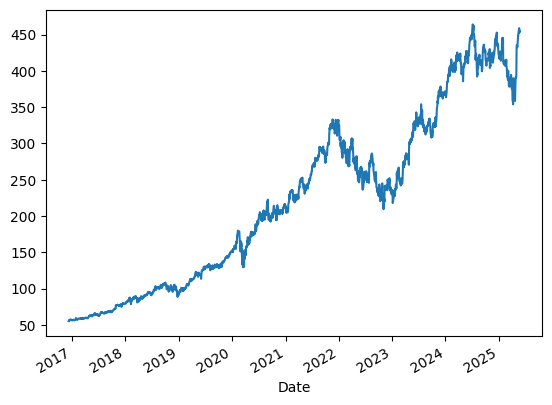

In [118]:
df.Close.plot()